# Feature Scaling on Titanic Dataset (Kaggle Train.csv)

**Dataset:** `titanic_encoded.csv` (891 rows × 11 columns)

This notebook demonstrates how to apply and compare different feature scaling techniques on the Titanic dataset.

**Features Overview:**
- `Survived` — Target variable (0 = No, 1 = Yes)
- `Pclass` — Passenger class (1, 2, 3) — *ordinal*
- `Name` — Passenger name — *text, not used for scaling*
- `Age` — Age in years — *continuous*
- `SibSp` — Number of siblings/spouses aboard — *discrete*
- `Parch` — Number of parents/children aboard — *discrete*
- `Ticket` — Ticket number — *text, not used for scaling*
- `Fare` — Passenger fare — *continuous, has outliers*
- `Sex_male` — Binary (1 = Male, 0 = Female)
- `Embarked_Q` — Binary (1 = Queenstown)
- `Embarked_S` — Binary (1 = Southampton)

**Features to Scale:** `Age`, `Fare`, `SibSp`, `Parch` (and optionally `Pclass`)

**Features to Leave As-Is:** `Sex_male`, `Embarked_Q`, `Embarked_S` (already 0/1)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

In [3]:
# Load the encoded Titanic dataset
df = pd.read_csv('../Dataset/titanic_encoded.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- First 5 Rows ---")
df.head()

Dataset shape: (891, 11)

Columns: ['Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

--- Data Types ---
Survived        int64
Pclass          int64
Name              str
Age           float64
SibSp           int64
Parch           int64
Ticket            str
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

--- Missing Values ---
Survived      0
Pclass        0
Name          0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

--- First 5 Rows ---


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


In [4]:
# Statistical summary of numeric columns
numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
print(df[numeric_cols].describe().round(2))

print("\n--- Feature Ranges ---")
for col in numeric_cols:
    print(f"{col:12s}: min={df[col].min():8.2f}, max={df[col].max():8.2f}, range={df[col].max()-df[col].min():8.2f}")

       Pclass     Age   SibSp   Parch    Fare  Sex_male  Embarked_Q  \
count  891.00  891.00  891.00  891.00  891.00    891.00      891.00   
mean     2.31   29.36    0.52    0.38   32.20      0.65        0.09   
std      0.84   13.02    1.10    0.81   49.69      0.48        0.28   
min      1.00    0.42    0.00    0.00    0.00      0.00        0.00   
25%      2.00   22.00    0.00    0.00    7.91      0.00        0.00   
50%      3.00   28.00    0.00    0.00   14.45      1.00        0.00   
75%      3.00   35.00    1.00    0.00   31.00      1.00        0.00   
max      3.00   80.00    8.00    6.00  512.33      1.00        1.00   

       Embarked_S  
count      891.00  
mean         0.73  
std          0.45  
min          0.00  
25%          0.00  
50%          1.00  
75%          1.00  
max          1.00  

--- Feature Ranges ---
Pclass      : min=    1.00, max=    3.00, range=    2.00
Age         : min=    0.42, max=   80.00, range=   79.58
SibSp       : min=    0.00, max=    8.00, 

## Why Scale the Titanic Features?

Look at the **ranges** above:
- `Fare`: 0.00 → 512.33 (huge range, contains outliers like $512)
- `Age`: 0.42 → 80.00 (moderate range)
- `SibSp`: 0 → 8 (small range)
- `Parch`: 0 → 6 (small range)
- `Pclass`: 1 → 3 (small, ordinal)

**Problem:** If we feed these into distance-based algorithms (KNN, SVM) or gradient-based models (Logistic Regression, Neural Networks), the `Fare` feature will **dominate** simply because its numbers are larger — not because it's more important.

**Solution:** Scale all features to a comparable range so each feature contributes fairly to the model.

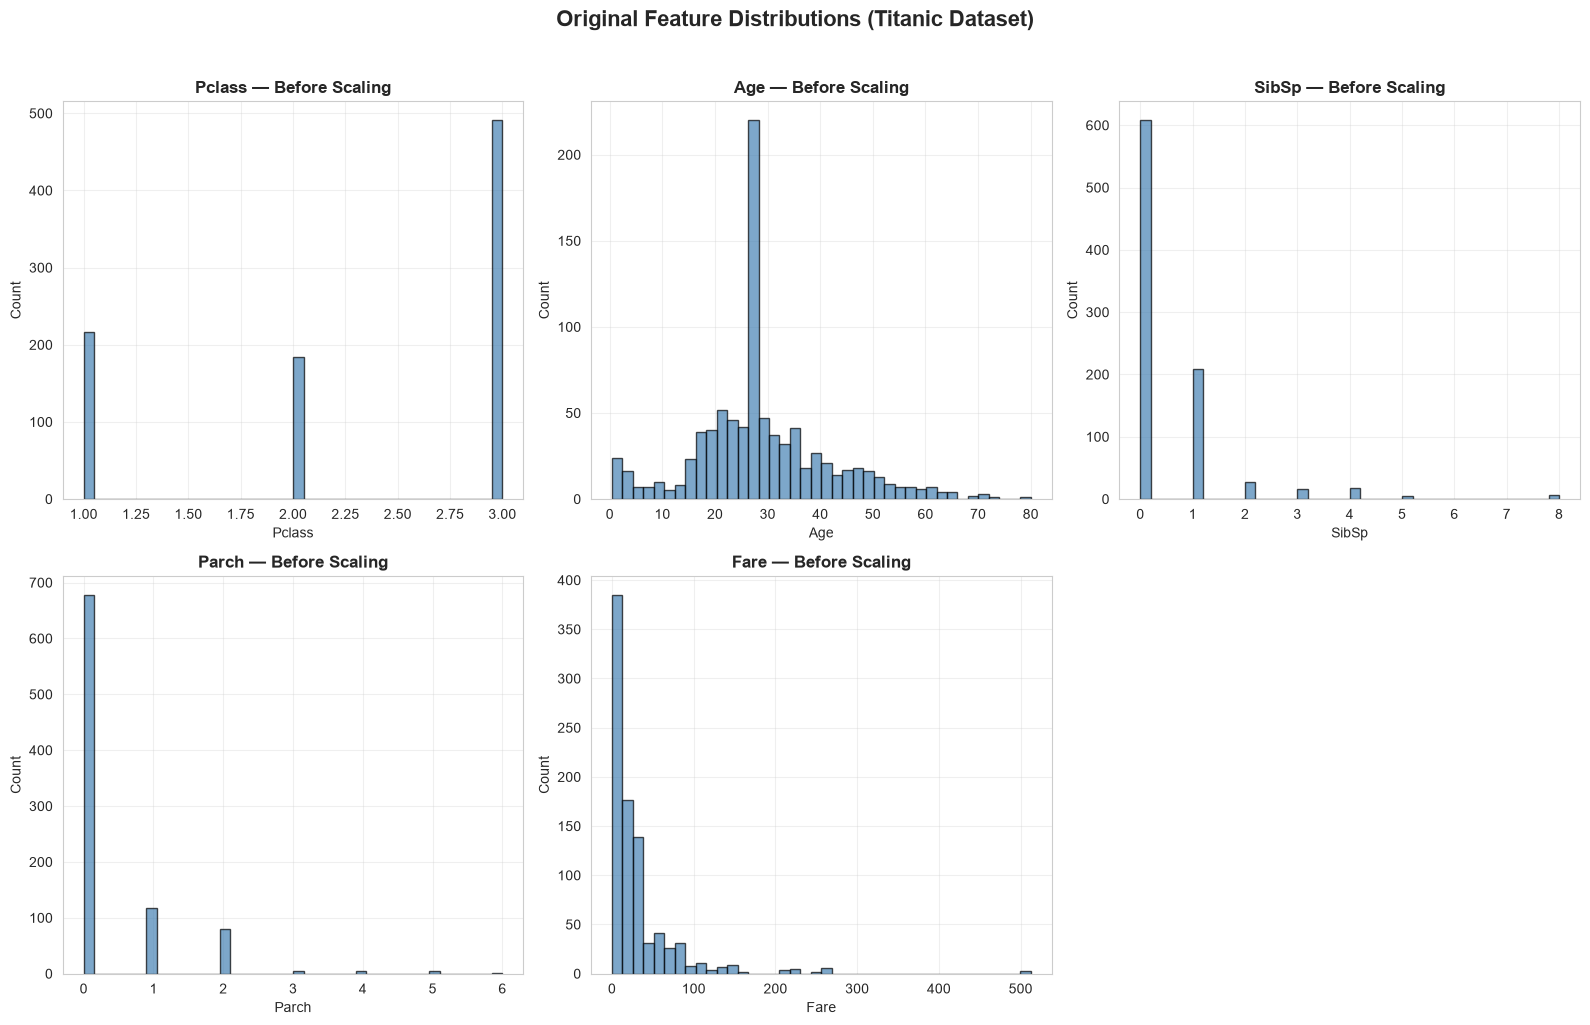

In [5]:
# Features we want to scale
features_to_scale = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(features_to_scale):
    axes[idx].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} — Before Scaling', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, alpha=0.3)

# Remove empty subplot
axes[-1].axis('off')

plt.suptitle('Original Feature Distributions (Titanic Dataset)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

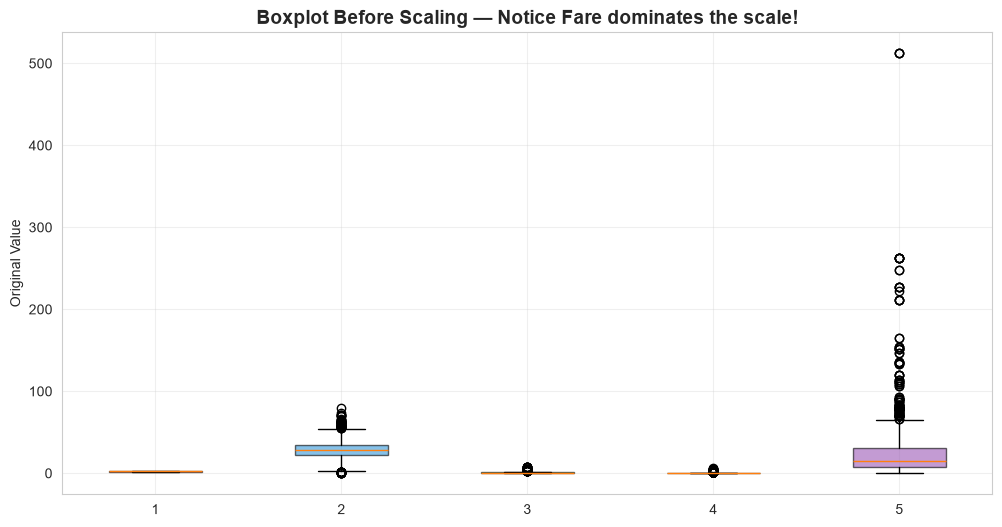

💡 The Fare box is stretched so high that Age, SibSp, Parch, and Pclass are invisible at the bottom!


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot([df[col] for col in features_to_scale], label=features_to_scale, patch_artist=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('Boxplot Before Scaling — Notice Fare dominates the scale!', fontsize=14, fontweight='bold')
ax.set_ylabel('Original Value')
ax.grid(True, alpha=0.3)
plt.show()

print("💡 The Fare box is stretched so high that Age, SibSp, Parch, and Pclass are invisible at the bottom!")

## 1. StandardScaler (Z-Score Standardization)

**Formula:** $x_{scaled} = \frac{x - \mu}{\sigma}$

- Mean becomes **0**, standard deviation becomes **1**
- Best for: Normally distributed features
- **Caution:** Sensitive to outliers (Fare has extreme values like $512)

In [7]:
# Apply StandardScaler
scaler_std = StandardScaler()
df_std = df.copy()
df_std[features_to_scale] = scaler_std.fit_transform(df[features_to_scale])

print("StandardScaler Results:")
print(df_std[features_to_scale].describe().round(4))

print("\n--- Verification ---")
print("Means (should be ~0):")
print(df_std[features_to_scale].mean().round(10))
print("\nStandard Deviations (should be ~1):")
print(df_std[features_to_scale].std().round(10))

StandardScaler Results:
         Pclass       Age     SibSp     Parch      Fare
count  891.0000  891.0000  891.0000  891.0000  891.0000
mean    -0.0000    0.0000    0.0000    0.0000    0.0000
std      1.0006    1.0006    1.0006    1.0006    1.0006
min     -1.5661   -2.2242   -0.4745   -0.4737   -0.6484
25%     -0.3694   -0.5657   -0.4745   -0.4737   -0.4891
50%      0.8274   -0.1046   -0.4745   -0.4737   -0.3574
75%      0.8274    0.4333    0.4328   -0.4737   -0.0242
max      0.8274    3.8916    6.7842    6.9741    9.6672

--- Verification ---
Means (should be ~0):
Pclass   -0.0
Age       0.0
SibSp     0.0
Parch     0.0
Fare      0.0
dtype: float64

Standard Deviations (should be ~1):
Pclass    1.000562
Age       1.000562
SibSp     1.000562
Parch     1.000562
Fare      1.000562
dtype: float64


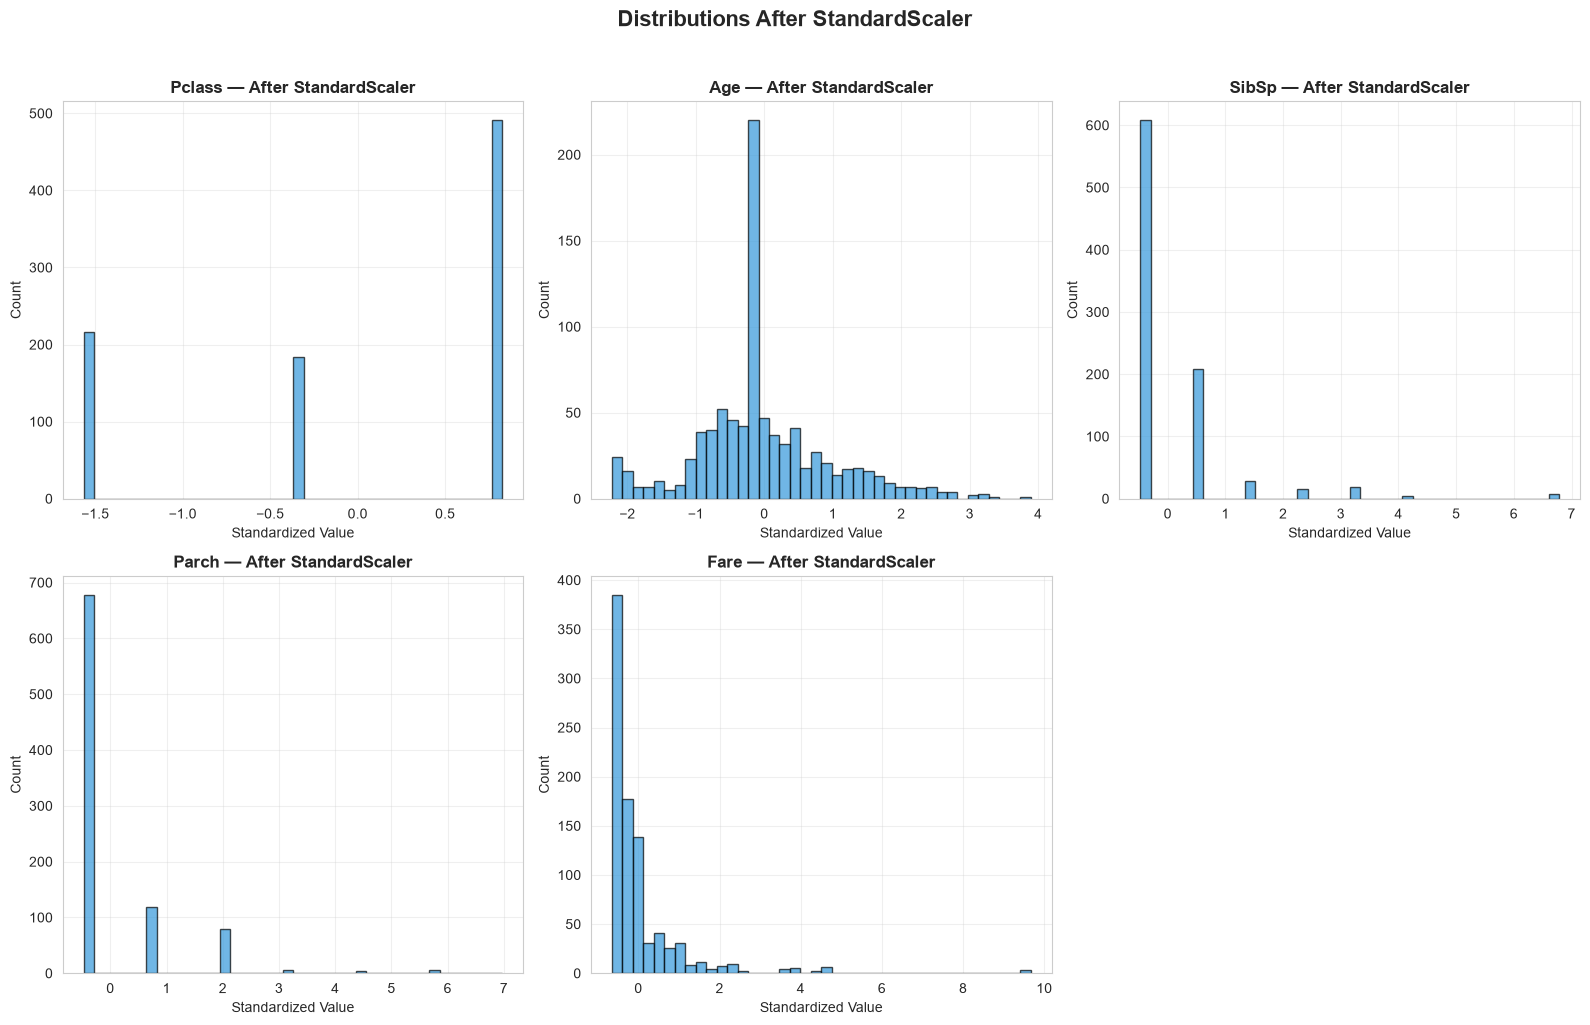

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(features_to_scale):
    axes[idx].hist(df_std[col], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} — After StandardScaler', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Standardized Value')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distributions After StandardScaler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. MinMaxScaler (Normalization to [0, 1])

**Formula:** 
$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- Scales to a **fixed range** [0, 1]
- Best for: Neural networks, when you need bounded output
- **Caution:** Very sensitive to outliers — one extreme Fare value ($512) compresses all other fares into a tiny range

In [9]:
# Apply MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[features_to_scale] = scaler_minmax.fit_transform(df[features_to_scale])

print("MinMaxScaler Results (range should be [0, 1]):")
print(df_minmax[features_to_scale].describe().round(4))

print("\n--- Min / Max Check ---")
print("Min values:")
print(df_minmax[features_to_scale].min().round(10))
print("\nMax values:")
print(df_minmax[features_to_scale].max().round(10))

MinMaxScaler Results (range should be [0, 1]):
         Pclass       Age     SibSp     Parch      Fare
count  891.0000  891.0000  891.0000  891.0000  891.0000
mean     0.6543    0.3637    0.0654    0.0636    0.0629
std      0.4180    0.1636    0.1378    0.1343    0.0970
min      0.0000    0.0000    0.0000    0.0000    0.0000
25%      0.5000    0.2712    0.0000    0.0000    0.0154
50%      1.0000    0.3466    0.0000    0.0000    0.0282
75%      1.0000    0.4345    0.1250    0.0000    0.0605
max      1.0000    1.0000    1.0000    1.0000    1.0000

--- Min / Max Check ---
Min values:
Pclass    0.0
Age       0.0
SibSp     0.0
Parch     0.0
Fare      0.0
dtype: float64

Max values:
Pclass    1.0
Age       1.0
SibSp     1.0
Parch     1.0
Fare      1.0
dtype: float64


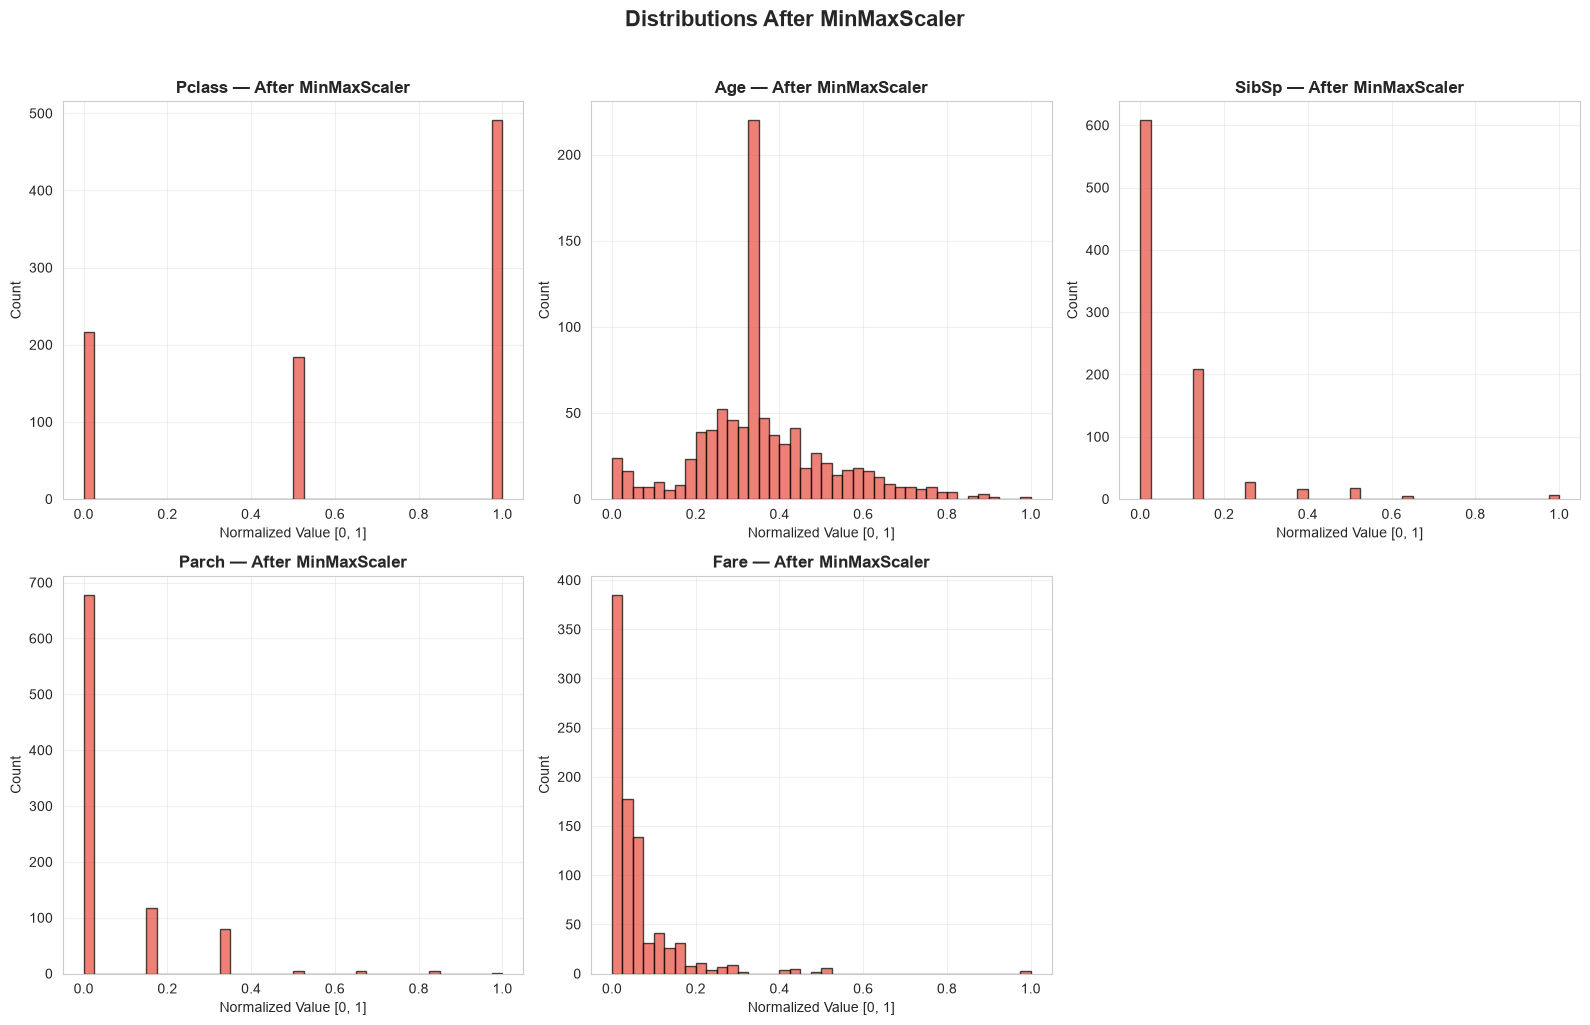

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(features_to_scale):
    axes[idx].hist(df_minmax[col], bins=40, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} — After MinMaxScaler', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Normalized Value [0, 1]')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xlim(-0.05, 1.05)
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distributions After MinMaxScaler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. RobustScaler (Robust to Outliers)

**Formula:** $x_{scaled} = \frac{x - Q_1}{Q_3 - Q_1}$ (uses median and IQR)

- Uses **median** and **Interquartile Range** instead of mean and std
- Best for: Data with outliers (Titanic `Fare` has extreme values!)
- The scaled values are NOT bounded — can go outside [-1, 1] for outliers

In [11]:
# Apply RobustScaler
scaler_robust = RobustScaler()
df_robust = df.copy()
df_robust[features_to_scale] = scaler_robust.fit_transform(df[features_to_scale])

print("RobustScaler Results:")
print(df_robust[features_to_scale].describe().round(4))

# Compare Fare across all three scalers
print("\n--- Fare Comparison Across Scalers ---")
fare_comparison = pd.DataFrame({
    'Original': df['Fare'],
    'StandardScaler': df_std['Fare'],
    'MinMaxScaler': df_minmax['Fare'],
    'RobustScaler': df_robust['Fare']
})
print(fare_comparison.describe().round(4))

RobustScaler Results:
         Pclass       Age     SibSp     Parch      Fare
count  891.0000  891.0000  891.0000  891.0000  891.0000
mean    -0.6914    0.1047    0.5230    0.3816    0.7687
std      0.8361    1.0015    1.1027    0.8061    2.1522
min     -2.0000   -2.1215    0.0000    0.0000   -0.6260
25%     -1.0000   -0.4615    0.0000    0.0000   -0.2834
50%      0.0000    0.0000    0.0000    0.0000    0.0000
75%      0.0000    0.5385    1.0000    0.0000    0.7166
max      0.0000    4.0000    8.0000    6.0000   21.5627

--- Fare Comparison Across Scalers ---
       Original  StandardScaler  MinMaxScaler  RobustScaler
count  891.0000        891.0000      891.0000      891.0000
mean    32.2042          0.0000        0.0629        0.7687
std     49.6934          1.0006        0.0970        2.1522
min      0.0000         -0.6484        0.0000       -0.6260
25%      7.9104         -0.4891        0.0154       -0.2834
50%     14.4542         -0.3574        0.0282        0.0000
75%     31.000

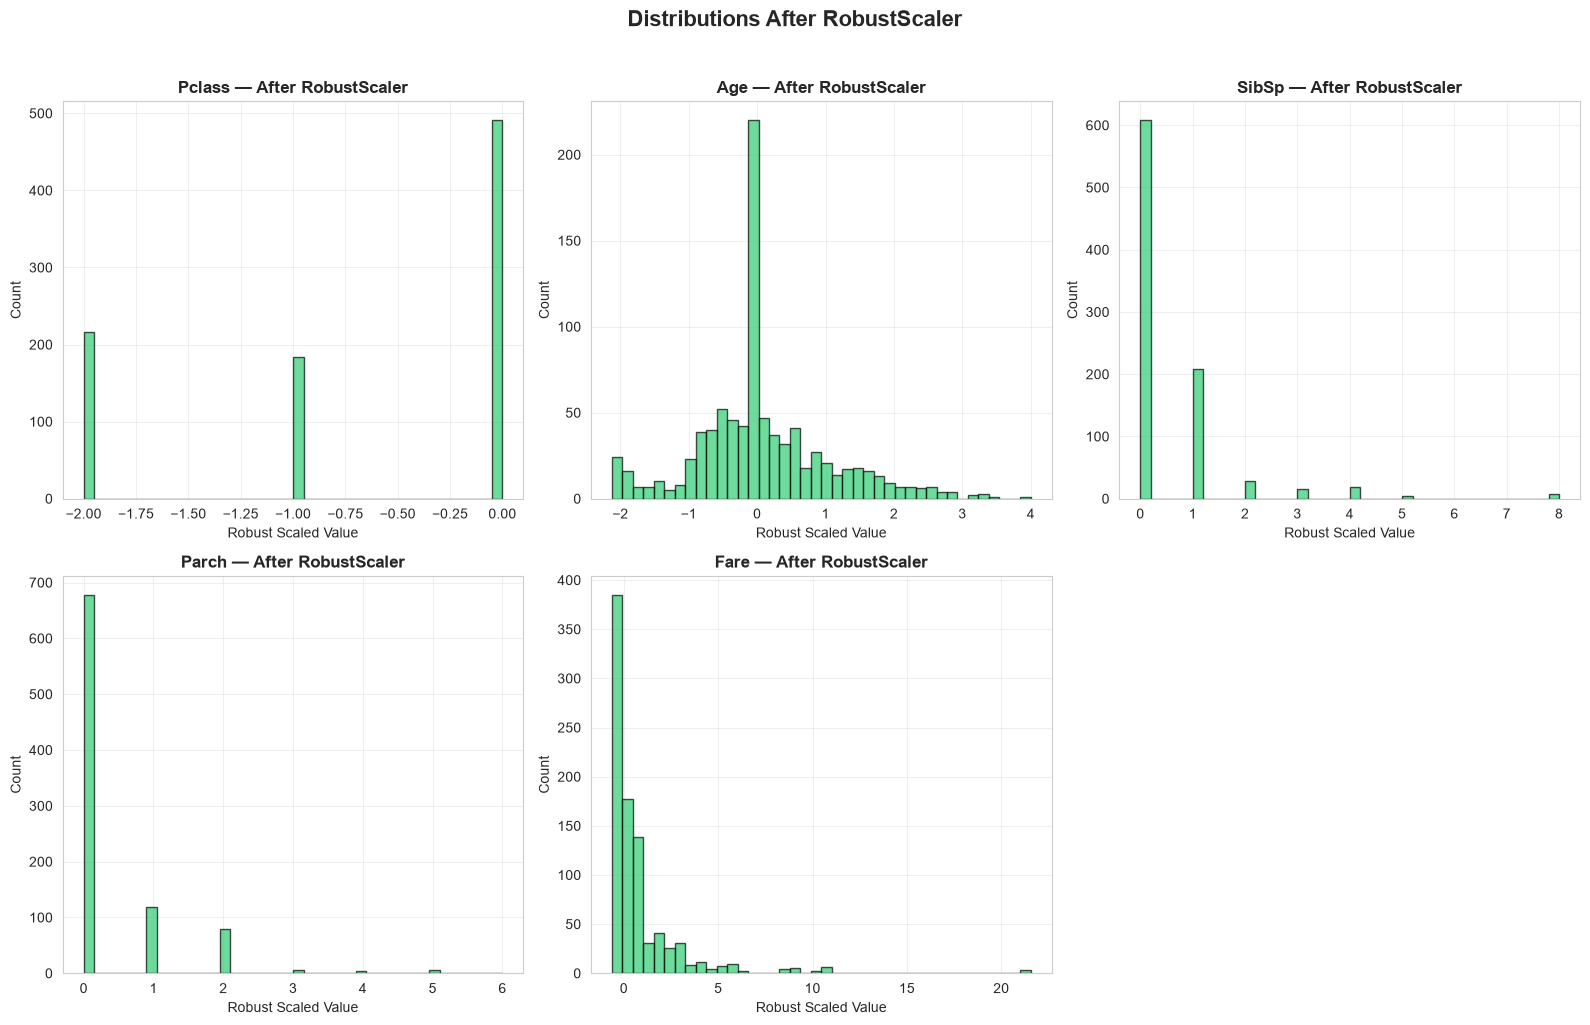

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(features_to_scale):
    axes[idx].hist(df_robust[col], bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} — After RobustScaler', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Robust Scaled Value')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distributions After RobustScaler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

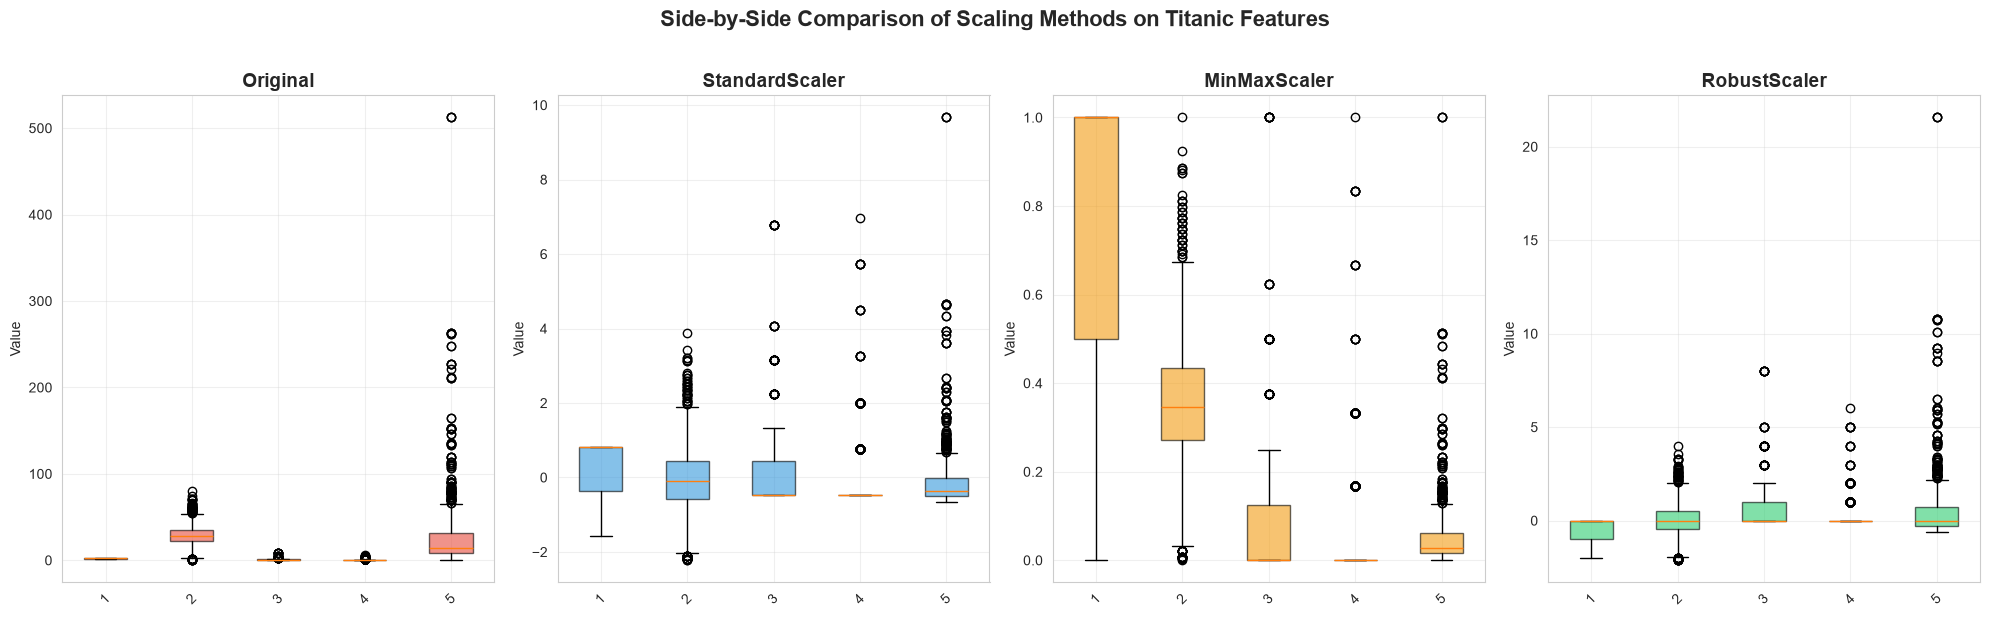

💡 Notice how RobustScaler handles the Fare outlier much better than StandardScaler and MinMaxScaler!


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

datasets = [df, df_std, df_minmax, df_robust]
titles = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

for ax, data, title, color in zip(axes, datasets, titles, colors):
    bp = ax.boxplot([data[col] for col in features_to_scale],
                    label=features_to_scale, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Side-by-Side Comparison of Scaling Methods on Titanic Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Notice how RobustScaler handles the Fare outlier much better than StandardScaler and MinMaxScaler!")

## 4. Real Impact on Model Performance

Let's train three algorithms that are sensitive to feature scaling and compare accuracy **with vs. without scaling**.

**Algorithms tested:**
- **KNN** — Distance-based, highly sensitive to scale
- **SVM** — Uses distance to hyperplane, sensitive to scale
- **Logistic Regression** — Gradient descent, benefits from scaling

In [14]:
# Prepare features (exclude text columns: Name, Ticket)
feature_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X = df[feature_cols]
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Results storage
results = []

for name, model in models.items():
    # Without scaling
    model.fit(X_train, y_train)
    acc_no_scale = accuracy_score(y_test, model.predict(X_test))
    
    # With StandardScaler
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    acc_std = accuracy_score(y_test, model.predict(X_test_s))
    
    # With RobustScaler
    scaler_r = RobustScaler()
    X_train_r = scaler_r.fit_transform(X_train)
    X_test_r = scaler_r.transform(X_test)
    model.fit(X_train_r, y_train)
    acc_robust = accuracy_score(y_test, model.predict(X_test_r))
    
    results.append({
        'Model': name,
        'No Scaling': f"{acc_no_scale:.4f}",
        'StandardScaler': f"{acc_std:.4f}",
        'RobustScaler': f"{acc_robust:.4f}",
        'Improvement (Std)': f"{(acc_std - acc_no_scale)*100:+.2f}%"
    })

results_df = pd.DataFrame(results)
print("=== Model Accuracy Comparison ===")
print(results_df.to_string(index=False))

=== Model Accuracy Comparison ===
              Model No Scaling StandardScaler RobustScaler Improvement (Std)
          KNN (k=5)     0.6592         0.8156       0.7486           +15.64%
          SVM (RBF)     0.6201         0.8101       0.8156           +18.99%
Logistic Regression     0.8045         0.8045       0.8045            +0.00%


=== 5-Fold Cross-Validation: KNN Accuracy ===
No Scaling:    0.6858 (+/- 0.0401)
StandardScaler: 0.8115 (+/- 0.0188)
RobustScaler:  0.7801 (+/- 0.0245)


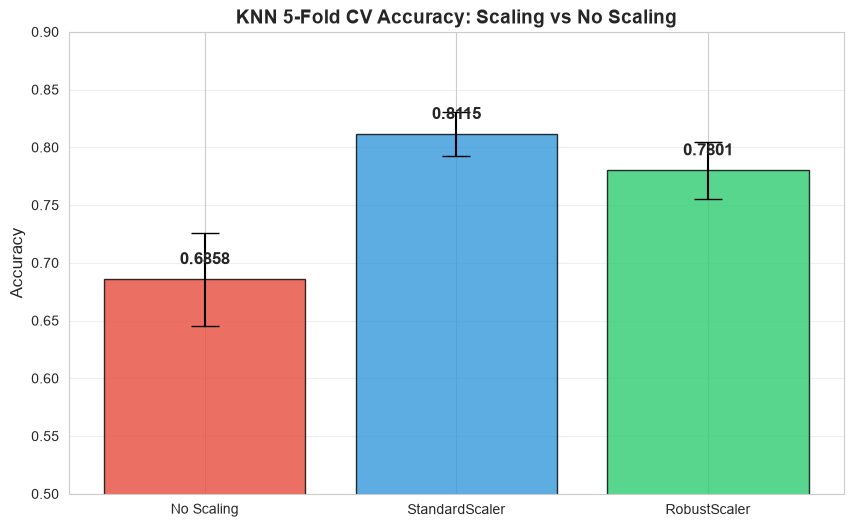

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [15]:
# Cross-validation for more robust comparison (KNN)
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

# No scaling
scores_raw = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

# StandardScaler via pipeline
pipe_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
scores_std = cross_val_score(pipe_std, X, y, cv=5, scoring='accuracy')

# RobustScaler via pipeline
pipe_robust = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
scores_robust = cross_val_score(pipe_robust, X, y, cv=5, scoring='accuracy')

print("=== 5-Fold Cross-Validation: KNN Accuracy ===")
print(f"No Scaling:    {scores_raw.mean():.4f} (+/- {scores_raw.std():.4f})")
print(f"StandardScaler: {scores_std.mean():.4f} (+/- {scores_std.std():.4f})")
print(f"RobustScaler:  {scores_robust.mean():.4f} (+/- {scores_robust.std():.4f})")

# Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['No Scaling', 'StandardScaler', 'RobustScaler']
means = [scores_raw.mean(), scores_std.mean(), scores_robust.mean()]
stds = [scores_raw.std(), scores_std.std(), scores_robust.std()]
bars = ax.bar(methods, means, yerr=stds, capsize=10,
              color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8, edgecolor='black')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('KNN 5-Fold CV Accuracy: Scaling vs No Scaling', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, 0.9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()
plt.tight_layout

## 5. Advanced: ColumnTransformer Pipeline

Not all features need the same scaler! Use `ColumnTransformer` to apply different scalers to different feature groups.

**Strategy for Titanic:**
- `Fare` → **RobustScaler** (has extreme outliers like $512)
- `Age` → **StandardScaler** (roughly normal distribution)
- `SibSp`, `Parch`, `Pclass` → **MinMaxScaler** (small discrete ranges)
- `Sex_male`, `Embarked_Q`, `Embarked_S` → **Passthrough** (already 0/1)

In [16]:
from sklearn.compose import ColumnTransformer

# Define feature groups
robust_features = ['Fare']          # Has outliers
standard_features = ['Age']         # Roughly normal
minmax_features = ['Pclass', 'SibSp', 'Parch']  # Small discrete ranges
passthrough_features = ['Sex_male', 'Embarked_Q', 'Embarked_S']  # Already 0/1

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_features),
        ('standard', StandardScaler(), standard_features),
        ('minmax', MinMaxScaler(), minmax_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    remainder='drop'  # Drop any columns not specified
)

# Fit and transform
X_transformed = preprocessor.fit_transform(X)

# Get feature names after transformation
feature_names_out = (
    robust_features + standard_features + minmax_features + passthrough_features
)

df_transformed = pd.DataFrame(X_transformed, columns=feature_names_out)

print("ColumnTransformer Pipeline Results:")
print(df_transformed.describe().round(4))

print("\n--- Feature Ranges After Custom Scaling ---")
for col in feature_names_out:
    print(f"{col:15s}: min={df_transformed[col].min():8.3f}, max={df_transformed[col].max():8.3f}")

ColumnTransformer Pipeline Results:
           Fare       Age    Pclass     SibSp     Parch  Sex_male  Embarked_Q  \
count  891.0000  891.0000  891.0000  891.0000  891.0000  891.0000    891.0000   
mean     0.7687    0.0000    0.6543    0.0654    0.0636    0.6476      0.0864   
std      2.1522    1.0006    0.4180    0.1378    0.1343    0.4780      0.2811   
min     -0.6260   -2.2242    0.0000    0.0000    0.0000    0.0000      0.0000   
25%     -0.2834   -0.5657    0.5000    0.0000    0.0000    0.0000      0.0000   
50%      0.0000   -0.1046    1.0000    0.0000    0.0000    1.0000      0.0000   
75%      0.7166    0.4333    1.0000    0.1250    0.0000    1.0000      0.0000   
max     21.5627    3.8916    1.0000    1.0000    1.0000    1.0000      1.0000   

       Embarked_S  
count    891.0000  
mean       0.7250  
std        0.4468  
min        0.0000  
25%        0.0000  
50%        1.0000  
75%        1.0000  
max        1.0000  

--- Feature Ranges After Custom Scaling ---
Fare     

# Full ML Pipeline with ColumnTransformer


In [17]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validate the full pipeline
cv_scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='accuracy')

print("=== Full Pipeline with ColumnTransformer ===")
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"All folds: {cv_scores.round(4)}")

# Compare with a simple StandardScaler pipeline
simple_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_simple = cross_val_score(simple_pipeline, X, y, cv=5, scoring='accuracy')
print(f"\nSimple StandardScaler Pipeline: {cv_scores_simple.mean():.4f} (+/- {cv_scores_simple.std():.4f})")
print(f"All folds: {cv_scores_simple.round(4)}")

=== Full Pipeline with ColumnTransformer ===
5-Fold CV Accuracy: 0.7901 (+/- 0.0192)
All folds: [0.7821 0.7921 0.7809 0.7697 0.8258]

Simple StandardScaler Pipeline: 0.7857 (+/- 0.0184)
All folds: [0.7709 0.7865 0.7809 0.7697 0.8202]


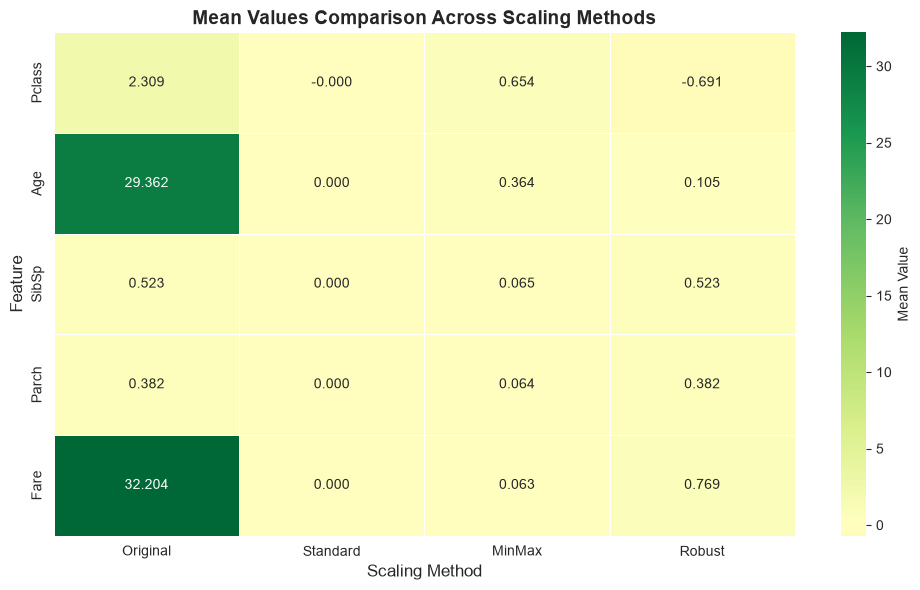

In [18]:
# Create a comparison heatmap of all scaled datasets
comparison_data = {
    'Original': df[features_to_scale].mean(),
    'Standard': df_std[features_to_scale].mean(),
    'MinMax': df_minmax[features_to_scale].mean(),
    'Robust': df_robust[features_to_scale].mean()
}
comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(comparison_df, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Value'})
ax.set_title('Mean Values Comparison Across Scaling Methods', fontsize=14, fontweight='bold')
ax.set_xlabel('Scaling Method', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Adding back the Survived feature to df_transformed and Finalizing it

In [27]:
# Add Survived target column
df_transformed["Survived"] = df["Survived"]
df_final = df_transformed.copy()

In [ ]:
df_final

,Fare,Age,Pclass,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Survived
0,-0.312011,-0.565736,1.0,0.125,0.000000,1.0,0.0,1.0,0
1,2.461242,0.663861,0.0,0.125,0.000000,0.0,0.0,0.0,1
2,-0.282777,-0.258337,1.0,0.000,0.000000,0.0,0.0,1.0,1
3,1.673732,0.433312,0.0,0.125,0.000000,0.0,0.0,1.0,1
4,-0.277363,0.433312,1.0,0.000,0.000000,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...
886,-0.062981,-0.181487,0.5,0.000,0.000000,1.0,0.0,1.0,0
887,0.673281,-0.796286,0.0,0.000,0.000000,0.0,0.0,1.0,1
888,0.389604,-0.104637,1.0,0.125,0.333333,0.0,0.0,1.0,0
889,0.673281,-0.258337,0.0,0.000,0.000000,1.0,0.0,0.0,1


## 13. Save the Encoded Dataset

This becomes the input for the next preprocessing stage: **Feature Engineering**.

In [34]:
output_path = '../Dataset/titanic_transformed-Scaled.csv'
df_final.to_csv(output_path, index=False)
print(f'Saved: {output_path}')

Saved: ../Dataset/titanic_transformed-Scaled.csv


## 6. Summary & Best Practices for Titanic

### Which Scaler to Use?

| Feature | Best Scaler | Reason |
|---------|-------------|--------|
| **Fare** | `RobustScaler` | Has extreme outliers ($512 vs median $14.45) |
| **Age** | `StandardScaler` | Roughly normal distribution, no extreme outliers |
| **SibSp** | `MinMaxScaler` or `StandardScaler` | Small discrete range (0-8) |
| **Parch** | `MinMaxScaler` or `StandardScaler` | Small discrete range (0-6) |
| **Pclass** | `MinMaxScaler` or leave as-is | Ordinal (1,2,3), already small range |
| **Sex_male** | `passthrough` | Already binary 0/1 |
| **Embarked_Q** | `passthrough` | Already binary 0/1 |
| **Embarked_S** | `passthrough` | Already binary 0/1 |

### Golden Rules

1. **Always `fit` on training data, `transform` on test data** — never fit on the full dataset!
2. **Use `Pipeline`** to prevent data leakage between train and test sets
3. **Tree-based models** (Random Forest, XGBoost) don't need scaling
4. **Distance-based models** (KNN, SVM, K-Means) absolutely need scaling
5. **When in doubt**, `StandardScaler` is the safest default choice
6. **If you see outliers**, switch to `RobustScaler`

### Quick Code Snippet

```python
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Best practice: ColumnTransformer + Pipeline
preprocessor = ColumnTransformer([
    ('robust', RobustScaler(), ['Fare']),
    ('standard', StandardScaler(), ['Age']),
    ('minmax', MinMaxScaler(), ['Pclass', 'SibSp', 'Parch']),
    ('pass', 'passthrough', ['Sex_male', 'Embarked_Q', 'Embarked_S'])
])

model = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
predictions = model.predict(X_test)
```